Today's topics:
* objects, attributes and methods
* `type`, `dir` and `help`
* attributes and methods of a `DataFrame`
* the `linregress` result

# Grain size and the strength of copper

We have typed a dot after a name for weeks: `my_list.append(6)`, `tests.head()`, `ax.plot(...)`, `fit.slope`.
Today we look at what that dot does.
First, a materials question to work on while we do it.

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/6/69/Microstructure_of_rolled_and_annealed_brass%3B_magnification_400X.jpg/960px-Microstructure_of_rolled_and_annealed_brass%3B_magnification_400X.jpg" alt="An etched, polished cross-section of brass under an optical microscope: a mosaic of irregular many-sided grains in shades of yellow and orange, separated by thin dark boundary lines" width=420/>

*Photo by Strangerhahaha, public domain, [via Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Microstructure_of_rolled_and_annealed_brass;_magnification_400X.jpg).*

Above: A polished and etched cross-section of rolled and annealed [brass](https://en.wikipedia.org/wiki/Brass), a copper-zinc alloy, at 400x magnification.
Each patch of one color is a **grain**, a region where the atoms form one continuous crystal.
Neighboring grains have their crystals tilted at different angles, and the thin dark lines are the **grain boundaries** where those orientations meet.
This image is brass rather than pure copper.
We use it only to identify grains and grain boundaries, which are also present in the copper specimens below.

A metal yields when planes of atoms slip past each other.
Line defects called dislocations produce that slip.
A dislocation glides easily through one grain.
At a boundary the neighboring crystal is tilted.
The slip planes do not line up, which stops the dislocation.
More dislocations arrive and pile up behind it.
Eventually the stress at the front of the pile-up is enough to start slip in the next grain.

Smaller grains mean more boundaries in any line across the sample.
They also mean shorter runs for a pile-up to build.
A fine-grained metal therefore needs a larger stress to yield.

The **Hall-Petch relation** quantifies this.
The yield strength $\sigma_y$ depends on the grain diameter $d$ as

$$\sigma_y = \sigma_0 + k_y\, d^{-1/2}$$

Here $\sigma_0$ is the stress to move a dislocation through a single large crystal, with no boundaries in the way.
The constant $k_y$ measures boundary resistance in MPa m$^{1/2}$.
A plot against $d^{-1/2}$ is linear.
`stats.linregress` from L13 can fit that line.

Our data are 32 synthetic copper specimens.
They were generated from published constants for annealed copper, with scatter added, so we know roughly what answer to hope for.
The grain diameter is in $\mu$m, and the file also holds $d^{-1/2}$ with $d$ converted to meters.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

hp = pd.read_csv('https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/hall_petch.csv')
hp.head()

,grain_size_um,inv_sqrt_grain_size,yield_strength_mpa
0,6.6,389.249,69.71
1,7.3,370.117,62.43
2,8.9,335.201,64.55
3,9.7,321.081,60.68
4,10.8,304.290,54.79


Each row is one specimen.
First the plain picture, yield strength against grain size, and then against $d^{-1/2}$.

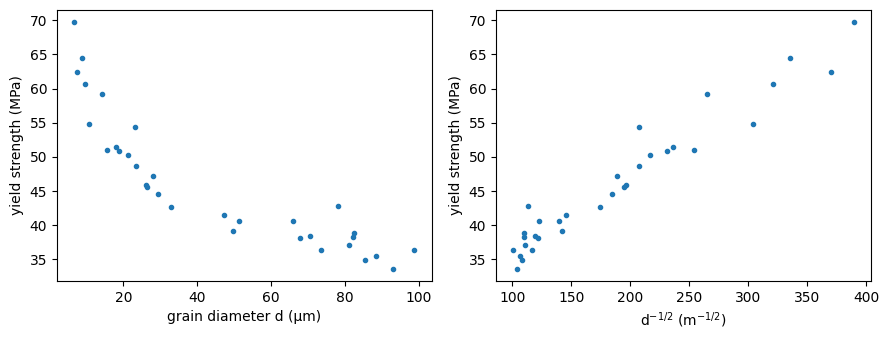

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].plot(hp['grain_size_um'], hp['yield_strength_mpa'], '.')
axes[0].set_xlabel('grain diameter d (µm)')
axes[0].set_ylabel('yield strength (MPa)')
axes[1].plot(hp['inv_sqrt_grain_size'], hp['yield_strength_mpa'], '.')
axes[1].set_xlabel('d$^{-1/2}$ (m$^{-1/2}$)')
axes[1].set_ylabel('yield strength (MPa)')
fig.tight_layout()

Strength climbs as the grains shrink, and the left panel bends.
Against $d^{-1/2}$ the points scatter around a straight line.

Before we fit that line, let's look at what the dot in `stats.linregress(...)` and `fit.slope` means.

# Everything is an object

In Python every value is an **object**.
An object is a value with attached names.
A dot selects one of those names.

You have already used a few.
`append` is attached to every list.

In [3]:
my_list = [5, 4, 3, 2, 1]
my_list.append(6)
print(my_list)
print(type(my_list))

[5, 4, 3, 2, 1, 6]
<class 'list'>


`type` reports what kind of object a name holds.
Now a toy array, four grain diameters in µm.

In [4]:
grain = np.array([12, 28, 45, 20])

print(type(grain))
print(grain.shape)
print(grain.mean())

<class 'numpy.ndarray'>
(4,)
26.25


Two different things are attached to this array, and they look different when we use them.

* `grain.shape` has **no parentheses**. It is an **attribute**, a value stored on the object.
* `grain.mean()` has **parentheses**. It is a **method**, a function attached to the object, and it computes something when we call it.

Leaving the parentheses off a method does not call it.
We get the method itself.

In [5]:
print(grain.mean)

<built-in method mean of numpy.ndarray object at 0x11343d230>


A dot has one job.
It selects a name attached to the object on its left.
If that name is a method, parentheses call it.
An attribute such as `shape` is already a value, so calling it is an error.

A method is attached to its own object, so the data do not have to be passed in.
`grain.mean()` and `np.mean(grain)` return the same number.

In [6]:
print(grain.mean(), np.mean(grain))

26.25 26.25


Adding parentheses to an attribute is an error.
The value `(4,)` is a tuple, and a tuple cannot be called.

In [7]:
# EXPECTED-ERROR: this cell fails on purpose -- see the surrounding text
print(grain.shape())

TypeError: 'tuple' object is not callable

# Finding what an object has: `dir` and `help`

We do not need to memorize what is attached to each kind of object.
`dir` returns a list of every name attached to an object.
The list for an array is long, so we ask whether particular names are in it, with `in` as in L16.

In [8]:
names = dir(grain)
print('shape' in names)
print('mean' in names)
print('volume' in names)

True
True
False


`shape` and `mean` are on the list, and `volume` is not.
Many other names on the list start and end with a double underscore, such as `__len__`.
Those are Python's own plumbing.

`dir` lists the names without separating attributes from methods.
`help` reads the documentation, as it did for our own functions in L18.

In [9]:
help(grain.mean)

Help on built-in function mean:

mean(...) method of numpy.ndarray instance
    a.mean(axis=None, dtype=None, out=None, keepdims=False, *, where=True)

    Returns the average of the array elements along given axis.

    Refer to `numpy.mean` for full documentation.

    See Also
    --------
    numpy.mean : equivalent function



The first line shows the call, `a.mean(axis=None, ...)`.
The call form, with parentheses and keyword arguments as in L18, marks this one as a method.

The rest of the hour uses `dir` and `help` on objects we already know: a `DataFrame`, the `fig` and `ax` from matplotlib, and the result of `linregress`.

# A `DataFrame` has attributes and methods

The table `hp` is a `DataFrame` object.

In [10]:
print(type(hp))

<class 'pandas.core.frame.DataFrame'>


We have used three of its attributes since L08.
Each one is a stored value, so there are no parentheses.

In [11]:
print(hp.shape)
print(hp.columns)
print(hp.dtypes)

(32, 3)
Index(['grain_size_um', 'inv_sqrt_grain_size', 'yield_strength_mpa'], dtype='object')
grain_size_um          float64
inv_sqrt_grain_size    float64
yield_strength_mpa     float64
dtype: object


`shape` is the same kind of tuple as for an array, 32 rows and 3 columns.
`columns` holds the column names and `dtypes` the type of each column.

Methods, with parentheses, do work on the table.
`.mean()` averages every column, `.describe()` summarizes each column, and `.head()` shows the first few rows.

In [12]:
print(hp.mean())

grain_size_um           44.853125
inv_sqrt_grain_size    188.998219
yield_strength_mpa      46.130000
dtype: float64


In [13]:
hp.describe()

,grain_size_um,inv_sqrt_grain_size,yield_strength_mpa
count,32.000000,32.000000,32.000000
mean,44.853125,188.998219,46.130000
std,30.654253,84.071027,9.585772
min,6.600000,100.605000,33.620000
25%,18.500000,115.812250,38.420000
50%,31.150000,179.385000,43.720000
75%,74.600000,232.526750,51.172500
max,98.800000,389.249000,69.710000


The specimens run from 6.6 µm to 98.8 µm in grain diameter, and from 33.6 MPa to 69.7 MPa in yield strength.
The mean grain diameter is 44.9 µm.

A method can take inputs.
`.head()` shows five rows unless we pass a number.
`.sort_values` takes a column name with `by=`, a keyword argument as in L18.

In [14]:
print(hp.head(3))

   grain_size_um  inv_sqrt_grain_size  yield_strength_mpa
0            6.6              389.249               69.71
1            7.3              370.117               62.43
2            8.9              335.201               64.55


In [15]:
by_strength = hp.sort_values(by='yield_strength_mpa', ascending=False)
print(by_strength.head(3))

   grain_size_um  inv_sqrt_grain_size  yield_strength_mpa
0            6.6              389.249               69.71
2            8.9              335.201               64.55
1            7.3              370.117               62.43


`sort_values` returned a new table named `by_strength`.
That table is another `DataFrame`, with its own `.head()` method.
The original `hp` is unchanged.

A single column is an object as well, with its own attributes and methods.

In [16]:
strength = hp['yield_strength_mpa']

print(type(strength))
print(strength.shape)
print(strength.max())

<class 'pandas.core.series.Series'>
(32,)
69.71


The matplotlib objects from L09 work the same way.
`fig` and `ax` are objects, and `ax.plot` is a method we have called since L09.
After the call, the axes hold what was drawn.

<class 'matplotlib.axes._axes.Axes'>
grain diameter d (µm)
1


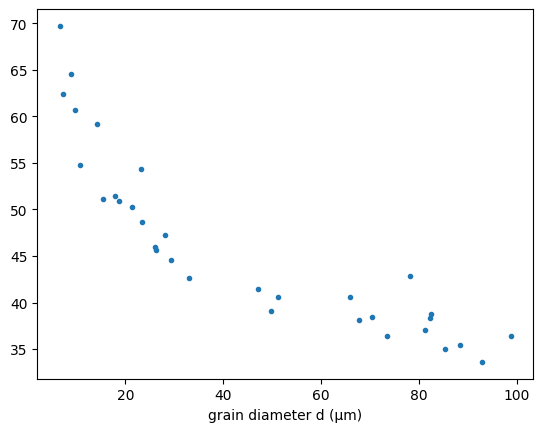

In [17]:
fig, ax = plt.subplots()
ax.plot(hp['grain_size_um'], strength, '.')
ax.set_xlabel('grain diameter d (µm)')

print(type(ax))
print(ax.get_xlabel())   # a method: reads back the label
print(len(ax.lines))     # an attribute: the list of lines drawn

### [Check your understanding]

Use the table `hp` and its column `strength = hp['yield_strength_mpa']`.

1. For each of `hp.shape`, `hp.head(3)`, `hp.dtypes` and `strength.max()`, write a comment saying whether it is an attribute or a method, and which part of the code you used to decide.
   Run each to check your answers.
2. Run `hp.shape()` and then `type(strength.max)`.
   In a sentence each, say what Python reported and why.
3. Check that `'values' in dir(strength)` and `'var' in dir(strength)` both print `True`.
   Run `strength.values` and `strength.var()`.
   Which is an attribute and which is a method?
   What type is each result?

*Optional follow-up.*
Run `help(hp.sort_values)` and find the `ascending` input.
Sort `hp` by `'grain_size_um'`, smallest first, and print the first three rows.
Then print `hp.head(3)`.
Is `hp` still in its original order? Explain in a sentence how you know.

# The result of `linregress`

We use the yield strength as `y` and $d^{-1/2}$ as `x`.

In [18]:
from scipy import stats

x = hp['inv_sqrt_grain_size']
y = hp['yield_strength_mpa']

fit = stats.linregress(x, y)
print(type(fit))

<class 'scipy.stats._stats_py.LinregressResult'>


The call returns one object.
The name `fit` refers to it.
It holds the results from L13 together, as in the picture from L11.

We check that the names we want are attached to it.

In [19]:
print('slope' in dir(fit))
print('stderr' in dir(fit))

True
True


These are attributes, so they are stored values and take no parentheses.
We used `slope`, `intercept` and `rvalue` in L13.
`stderr` and `intercept_stderr` are the standard errors of the slope and the intercept, the same idea as `perr` in L19.

In [20]:
print(f'slope     = {fit.slope:.4f} MPa m^0.5')
print(f'intercept = {fit.intercept:.1f} MPa')
print(f'rvalue    = {fit.rvalue:.3f}')

slope     = 0.1106 MPa m^0.5
intercept = 25.2 MPa
rvalue    = 0.970


Compare this with `curve_fit` in L19, which returned two arrays, `popt` and `pcov`, in a fixed order.
Here one object holds everything, and each value has a name.

The fitted parameters have the following materials interpretations.

* $k_y = 0.1106$ MPa m$^{1/2}$. Every extra 100 m$^{-1/2}$ of $d^{-1/2}$ adds about 11 MPa of yield strength. This is the boundary-strengthening constant.
* $\sigma_0 = 25.2$ MPa is the intercept, the yield strength extrapolated to $d^{-1/2} = 0$, a grain of infinite size. It is the friction stress to move a dislocation through a single crystal, so it is a real quantity here.
* $R^2$ is `fit.rvalue**2`.

In [21]:
print(f'R2 = {fit.rvalue**2:.3f}')
print(f'k_y     = {fit.slope:.4f} ± {fit.stderr:.4f} MPa m^0.5')
print(f'sigma_0 = {fit.intercept:.1f} ± {fit.intercept_stderr:.1f} MPa')

R2 = 0.941
k_y     = 0.1106 ± 0.0050 MPa m^0.5
sigma_0 = 25.2 ± 1.0 MPa


The published constants for annealed copper that we generated the data from are 25 MPa and 0.11 MPa m$^{1/2}$.
Both fall within about one standard error of the fitted values.

Reading `fit.slope()` with parentheses fails the same way `grain.shape()` did, because the slope is a stored number.

Friday's `minimize` returns another object of this kind, read with `.x`, `.fun` and `.success`.

# Summary

* Every value in Python is an **object**. A dot selects a name attached to the object on its left.
* An **attribute** is a stored value and takes no parentheses: `grain.shape`, `hp.columns`, `fit.slope`.
* A **method** is a function attached to the object and takes parentheses: `grain.mean()`, `hp.head(3)`, `ax.plot(...)`. Without parentheses we get the method itself.
* `type(obj)` names the kind of object. `dir(obj)` lists its names, and `'name' in dir(obj)` checks for one. `help(obj.name)` shows the documentation for one of them.
* A method that returns a new object, like `hp.sort_values(...)`, leaves the original unchanged. The new object has its own methods.
* `stats.linregress` returns one object with the named attributes `slope`, `intercept`, `rvalue`, `stderr` and `intercept_stderr`.
* In the Hall-Petch fit, the slope is the boundary-strengthening constant $k_y$ and the intercept is the friction stress $\sigma_0$.

# Quiz 6 warm-up

In Q1 you will:
- read a short function from [L17](https://colab.research.google.com/github/wfreinhart/matse219/blob/main/notebooks/Lecture17.ipynb) that has a `print` or a `return`, and the lines that use its result,
- say what the call returned and what happened to the line that followed,
- and explain what goes wrong when the arguments are in a different order.

In Q2 you will:
- read a function from [L18](https://colab.research.google.com/github/wfreinhart/matse219/blob/main/notebooks/Lecture18.ipynb) that returns two values and has a default for one parameter,
- say what a call prints and which value each name received,
- and explain what the default contributed to the answer.

Objects, from today, are not on the quiz.

## Further reading

* VanderPlas, *A Whirlwind Tour of Python*, "Basic Python Semantics: Objects and Variables"
* [`scipy.stats.linregress` documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.linregress.html), including the attributes of the result
* Hansen, "Hall-Petch relation and boundary strengthening," *Scripta Materialia* 51 (2004) 801-806, [DOI 10.1016/j.scriptamat.2004.06.002](https://doi.org/10.1016/j.scriptamat.2004.06.002)
* Photo credit: rolled and annealed brass, Strangerhahaha, public domain, [Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Microstructure_of_rolled_and_annealed_brass;_magnification_400X.jpg)

# Appendix A: The same fit with `curve_fit`

Optional.
L19's `curve_fit` fits the Hall-Petch line too, if we write the line as a model function.
It returns `popt` and `pcov`, and the numbers should match the attributes of `fit`.

In [22]:
from scipy import optimize

def hall_petch(x, sigma_0, k_y):
    """Yield strength in MPa from sigma_0 + k_y * x, where x is d**-0.5 in m**-0.5."""
    return sigma_0 + k_y * x

popt, pcov = optimize.curve_fit(hall_petch, x, y)
perr = np.sqrt(np.diag(pcov))

print(f'curve_fit: sigma_0 = {popt[0]:.2f} ± {perr[0]:.2f} MPa, k_y = {popt[1]:.4f} ± {perr[1]:.4f} MPa m^0.5')
print(f'linregress: sigma_0 = {fit.intercept:.2f} ± {fit.intercept_stderr:.2f} MPa, k_y = {fit.slope:.4f} ± {fit.stderr:.4f} MPa m^0.5')

curve_fit: sigma_0 = 25.22 ± 1.04 MPa, k_y = 0.1106 ± 0.0050 MPa m^0.5
linregress: sigma_0 = 25.22 ± 1.04 MPa, k_y = 0.1106 ± 0.0050 MPa m^0.5


A straight line is a model that both tools can fit, and both report the same values and standard errors.
`linregress` stores them as named attributes, and `curve_fit` stores them by position in two arrays.

# Appendix B: Prediction and the fitted line

Optional.
The same attributes work in a formula.
A copper specimen with 20 µm grains has $d = 20\times10^{-6}$ m.

In [23]:
d = 20e-6   # m
sigma_pred = fit.intercept + fit.slope / np.sqrt(d)
print(f'predicted yield strength at 20 µm: {sigma_pred:.1f} MPa')

predicted yield strength at 20 µm: 50.0 MPa


We build the fitted line from the two attributes, as we did in L13.

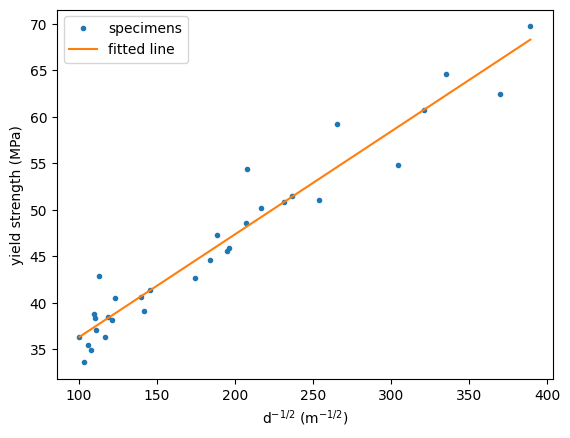

In [24]:
x_line = np.array([np.min(x), np.max(x)])
y_line = fit.slope * x_line + fit.intercept

fig, ax = plt.subplots()
ax.plot(x, y, '.', label='specimens')
ax.plot(x_line, y_line, '-', label='fitted line')
ax.set_xlabel('d$^{-1/2}$ (m$^{-1/2}$)')
ax.set_ylabel('yield strength (MPa)')
ax.legend()

# Appendix C: Methods that change the object

Optional.
`hp.sort_values(...)` returned a new table.
Some methods instead change the object they belong to, and return nothing.
The list `.sort()` method is one.

In [25]:
grain_list = [12, 28, 45, 20]
result = grain_list.sort()

print(result)
print(grain_list)

None
[12, 20, 28, 45]


The call changed `grain_list` in place and returned `None`, so `result` holds `None`.
The original order is gone.
This is the opposite of `hp.sort_values(...)`, which returned a sorted copy and did not change `hp`.
Which one a method does is written in its documentation, so `help(grain_list.sort)` is the place to check.